# Homework 4: Decision Trees and Naive Bayes
**Name:** Neha Mahesh

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, roc_curve
)

In [32]:
# SPAMBASE: 57 features + 1 label column
spam_cols = [f'f{i}' for i in range(57)] + ['label']
spam_df = pd.read_csv('spambase.data', header=None, names=spam_cols)

X_spam = spam_df.iloc[:, :57].values
y_spam = spam_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_spam, y_spam, test_size=0.3, random_state=42, stratify=y_spam
)

print(f'SPAMBASE — Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Class balance (train spam rate): {y_train.mean():.3f}')

SPAMBASE — Train: (3220, 57), Test: (1381, 57)
Class balance (train spam rate): 0.394


---
# Problem 1: Decision Trees

## Part 1: Information Gain (Entropy) — No Pruning

In [34]:
def eval_metrics(model, X_tr, y_tr, X_te, y_te, label=''):
    """Compute and print train/test error, accuracy, F1, AUC."""
    results = {}
    for split, X, y in [('Train', X_tr, y_tr), ('Test', X_te, y_te)]:
        pred = model.predict(X)
        prob = model.predict_proba(X)[:, 1]
        acc  = accuracy_score(y, pred)
        err  = 1 - acc
        f1   = f1_score(y, pred)
        auc  = roc_auc_score(y, prob)
        results[split] = dict(error=err, accuracy=acc, f1=f1, auc=auc)
        print(f"{label} {split}: Error={err:.4f}, Accuracy={acc:.4f}, F1={f1:.4f}, AUC={auc:.4f}")
    return results

# Train unpruned tree with entropy (information gain)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

print('=== Decision Tree: Information Gain (no pruning) ===')
res_entropy = eval_metrics(dt_entropy, X_train, y_train, X_test, y_test, label='Entropy')
print(f'Tree depth: {dt_entropy.get_depth()}')

=== Decision Tree: Information Gain (no pruning) ===
Entropy Train: Error=0.0003, Accuracy=0.9997, F1=0.9996, AUC=1.0000
Entropy Test: Error=0.0717, Accuracy=0.9283, F1=0.9086, AUC=0.9241
Tree depth: 20


## Part 2: Gini Index — No Pruning

In [36]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

print('=== Decision Tree: Gini Index (no pruning) ===')
res_gini = eval_metrics(dt_gini, X_train, y_train, X_test, y_test, label='Gini')
print(f'Tree depth: {dt_gini.get_depth()}')

=== Decision Tree: Gini Index (no pruning) ===
Gini Train: Error=0.0003, Accuracy=0.9997, F1=0.9996, AUC=1.0000
Gini Test: Error=0.1079, Accuracy=0.8921, F1=0.8659, AUC=0.8907
Tree depth: 32


## Part 3: Pruning by Maximum Depth

Optimal depth (min test error): 16
Test error at optimal depth: 0.0637


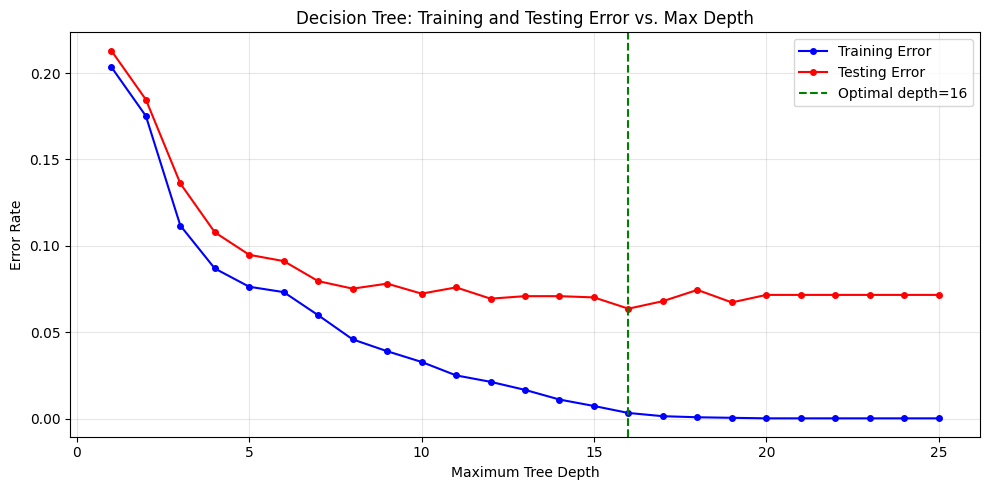

In [38]:
depths = list(range(1, 26))
train_errors, test_errors = [], []

for d in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_errors.append(1 - accuracy_score(y_train, clf.predict(X_train)))
    test_errors.append(1 - accuracy_score(y_test, clf.predict(X_test)))

optimal_depth = depths[np.argmin(test_errors)]
print(f'Optimal depth (min test error): {optimal_depth}')
print(f'Test error at optimal depth: {min(test_errors):.4f}')

plt.figure(figsize=(10, 5))
plt.plot(depths, train_errors, 'b-o', label='Training Error', markersize=4)
plt.plot(depths, test_errors, 'r-o', label='Testing Error', markersize=4)
plt.axvline(x=optimal_depth, color='green', linestyle='--', label=f'Optimal depth={optimal_depth}')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Error Rate')
plt.title('Decision Tree: Training and Testing Error vs. Max Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p1_depth_vs_error.png', dpi=150)
plt.show()

---
# Problem 2: Random Forest Ensemble

## Part 1 & 2: Train for T ∈ {10, 50, 100, 500} and Compare with Decision Tree

In [40]:
T_values = [10, 50, 100, 500]
rf_results = {}

print('=== Random Forest Results ===')
for T in T_values:
    rf = RandomForestClassifier(n_estimators=T, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    row = {}
    for split, X, y in [('train', X_train, y_train), ('test', X_test, y_test)]:
        pred = rf.predict(X)
        prob = rf.predict_proba(X)[:, 1]
        row[f'{split}_acc']  = accuracy_score(y, pred)
        row[f'{split}_f1']   = f1_score(y, pred)
        row[f'{split}_auc']  = roc_auc_score(y, prob)
    rf_results[T] = {'model': rf, **row}
    print(f"T={T:>3}: Train Acc={row['train_acc']:.4f} F1={row['train_f1']:.4f} AUC={row['train_auc']:.4f} "
          f"| Test Acc={row['test_acc']:.4f} F1={row['test_f1']:.4f} AUC={row['test_auc']:.4f}")

# Comparison table
print('\n=== Comparison: Decision Tree (best depth) vs. Random Forest ===')
best_dt = DecisionTreeClassifier(criterion='entropy', max_depth=optimal_depth, random_state=42)
best_dt.fit(X_train, y_train)
eval_metrics(best_dt, X_train, y_train, X_test, y_test, label=f'DT(depth={optimal_depth})')
print(f'RF(T=100) Test Acc={rf_results[100]["test_acc"]:.4f} F1={rf_results[100]["test_f1"]:.4f} AUC={rf_results[100]["test_auc"]:.4f}')

=== Random Forest Results ===
T= 10: Train Acc=0.9960 F1=0.9949 AUC=0.9998 | Test Acc=0.9442 F1=0.9270 AUC=0.9812
T= 50: Train Acc=0.9991 F1=0.9988 AUC=1.0000 | Test Acc=0.9544 F1=0.9411 AUC=0.9849
T=100: Train Acc=0.9997 F1=0.9996 AUC=1.0000 | Test Acc=0.9558 F1=0.9430 AUC=0.9859
T=500: Train Acc=0.9997 F1=0.9996 AUC=1.0000 | Test Acc=0.9566 F1=0.9439 AUC=0.9863

=== Comparison: Decision Tree (best depth) vs. Random Forest ===
DT(depth=16) Train: Error=0.0034, Accuracy=0.9966, F1=0.9957, AUC=0.9999
DT(depth=16) Test: Error=0.0637, Accuracy=0.9363, F1=0.9187, AUC=0.9361
RF(T=100) Test Acc=0.9558 F1=0.9430 AUC=0.9859


## Part 3: Variable Importance

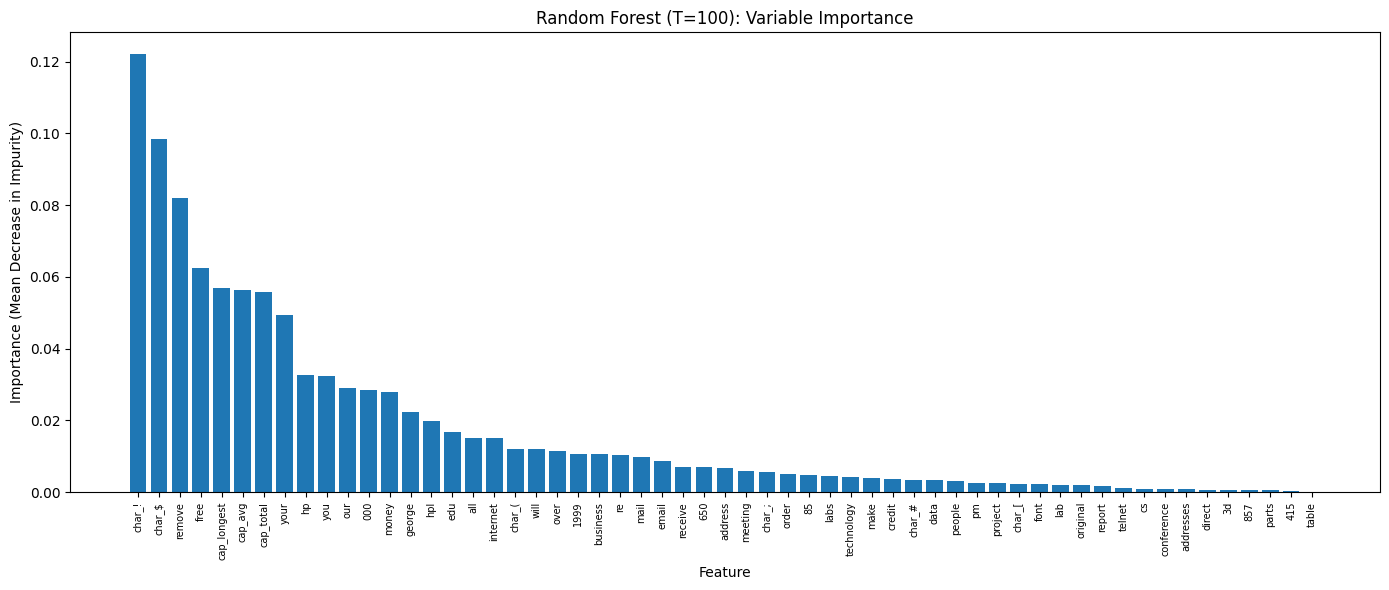

Top 10 most important features:
  1. char_!: 0.1220
  2. char_$: 0.0983
  3. remove: 0.0819
  4. free: 0.0625
  5. cap_longest: 0.0568
  6. cap_avg: 0.0563
  7. cap_total: 0.0558
  8. your: 0.0493
  9. hp: 0.0328
  10. you: 0.0323


In [42]:
# Use RF with 100 trees for feature importance
rf100 = rf_results[100]['model']
importances = rf100.feature_importances_
indices = np.argsort(importances)[::-1]

# Feature names from spambase.names
word_features = [
    'make','address','all','3d','our','over','remove','internet','order','mail',
    'receive','will','people','report','addresses','free','business','email','you',
    'credit','your','font','000','money','hp','hpl','george','650','lab','labs',
    'telnet','857','data','415','85','technology','1999','parts','pm','direct',
    'cs','meeting','original','project','re','edu','table','conference',
    'char_;','char_(','char_[','char_!','char_$','char_#',
    'cap_avg','cap_longest','cap_total'
]
feature_names = word_features[:57]

plt.figure(figsize=(14, 6))
plt.bar(range(57), importances[indices], align='center')
plt.xticks(range(57), [feature_names[i] for i in indices], rotation=90, fontsize=7)
plt.xlabel('Feature')
plt.ylabel('Importance (Mean Decrease in Impurity)')
plt.title('Random Forest (T=100): Variable Importance')
plt.tight_layout()
plt.savefig('p2_variable_importance.png', dpi=150)
plt.show()

print('Top 10 most important features:')
for rank, i in enumerate(indices[:10], 1):
    print(f'  {rank}. {feature_names[i]}: {importances[i]:.4f}')

---
# Problem 3: AdaBoost Ensemble

## Part 1 & 2:

In [72]:
ada_results = {}

print('=== AdaBoost Results ===')
for T in T_values:
    base = DecisionTreeClassifier(max_depth=1, random_state=42)
    ada = AdaBoostClassifier(estimator=base, n_estimators=T, random_state=42, algorithm='SAMME')
    ada.fit(X_train, y_train)
    row = {}
    for split, X, y in [('train', X_train, y_train), ('test', X_test, y_test)]:
        pred = ada.predict(X)
        prob = ada.predict_proba(X)[:, 1]
        row[f'{split}_acc']  = accuracy_score(y, pred)
        row[f'{split}_f1']   = f1_score(y, pred)
        row[f'{split}_auc']  = roc_auc_score(y, prob)
    ada_results[T] = {'model': ada, **row}
    print(f"T={T:>3}: Train Acc={row['train_acc']:.4f} F1={row['train_f1']:.4f} AUC={row['train_auc']:.4f} "
          f"| Test Acc={row['test_acc']:.4f} F1={row['test_f1']:.4f} AUC={row['test_auc']:.4f}")

# Side-by-side comparison
print('\n=== RF vs. AdaBoost Comparison (Test Set) ===')
print(f'{"T":>5} | {"RF Acc":>8} {"RF F1":>8} {"RF AUC":>8} | {"ADA Acc":>8} {"ADA F1":>8} {"ADA AUC":>8}')
print('-' * 70)
for T in T_values:
    r, a = rf_results[T], ada_results[T]
    print(f"{T:>5} | {r['test_acc']:>8.4f} {r['test_f1']:>8.4f} {r['test_auc']:>8.4f} "
          f"| {a['test_acc']:>8.4f} {a['test_f1']:>8.4f} {a['test_auc']:>8.4f}")

=== AdaBoost Results ===
T= 10: Train Acc=0.9040 F1=0.8784 AUC=0.9627 | Test Acc=0.8979 F1=0.8703 AUC=0.9589
T= 50: Train Acc=0.9345 F1=0.9148 AUC=0.9820 | Test Acc=0.9269 F1=0.9046 AUC=0.9782
T=100: Train Acc=0.9413 F1=0.9244 AUC=0.9851 | Test Acc=0.9334 F1=0.9145 AUC=0.9813
T=500: Train Acc=0.9516 F1=0.9381 AUC=0.9901 | Test Acc=0.9385 F1=0.9211 AUC=0.9834

=== RF vs. AdaBoost Comparison (Test Set) ===
    T |   RF Acc    RF F1   RF AUC |  ADA Acc   ADA F1  ADA AUC
----------------------------------------------------------------------
   10 |   0.9442   0.9270   0.9812 |   0.8979   0.8703   0.9589
   50 |   0.9544   0.9411   0.9849 |   0.9269   0.9046   0.9782
  100 |   0.9558   0.9430   0.9859 |   0.9334   0.9145   0.9813
  500 |   0.9566   0.9439   0.9863 |   0.9385   0.9211   0.9834


## Part 3: ROC Curves — Decision Tree vs. RF(100) vs. AdaBoost(100)

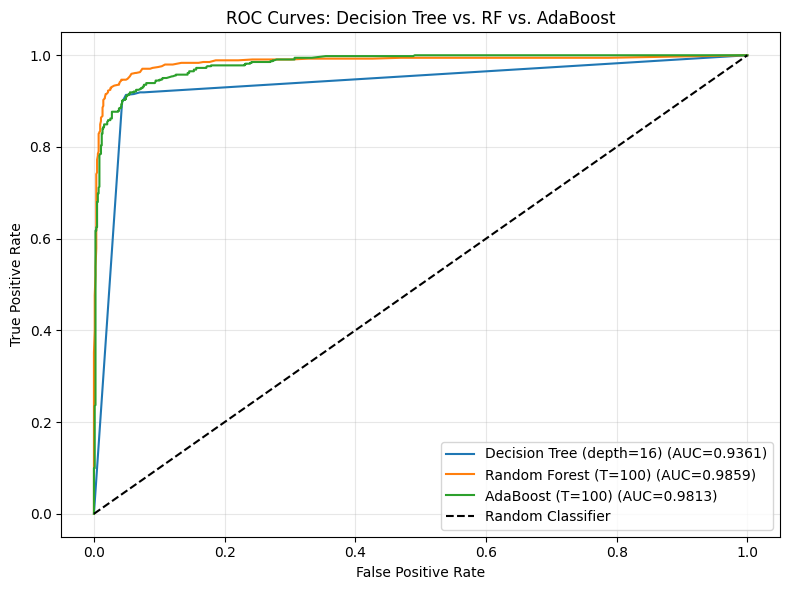

In [70]:
plt.figure(figsize=(8, 6))

models_to_plot = [
    (best_dt, f'Decision Tree (depth={optimal_depth})'),
    (rf_results[100]['model'], 'Random Forest (T=100)'),
    (ada_results[100]['model'], 'AdaBoost (T=100)'),
]

for model, label in models_to_plot:
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{label} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Decision Tree vs. RF vs. AdaBoost')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p3_roc_curves.png', dpi=150)
plt.show()

---
# Problem 4: Naive Bayes Classifier

## Data Loading and Preprocessing (Mushroom Dataset)

In [68]:
# Column names from UCI documentation
mushroom_cols = [
    'class','cap-shape','cap-surface','cap-color','bruises','odor',
    'gill-attachment','gill-spacing','gill-size','gill-color','stalk-shape',
    'stalk-root','stalk-surface-above-ring','stalk-surface-below-ring',
    'stalk-color-above-ring','stalk-color-below-ring','veil-type','veil-color',
    'ring-number','ring-type','spore-print-color','population','habitat'
]

mush_df = pd.read_csv('agaricus-lepiota.data', header=None, names=mushroom_cols)
print(f'Mushroom dataset: {mush_df.shape}')
print(f'Class distribution:\n{mush_df["class"].value_counts()}')

# Label encode all columns so each category becomes an integer
encoders = {}
mush_encoded = mush_df.copy()
for col in mush_encoded.columns:
    le = LabelEncoder()
    mush_encoded[col] = le.fit_transform(mush_encoded[col])
    encoders[col] = le

# Class: 'e'->0 (edible), 'p'->1 (poisonous) after encoding
# Let's confirm mapping
print(f'Class encoding: {dict(zip(encoders["class"].classes_, encoders["class"].transform(encoders["class"].classes_)))}')

X_mush = mush_encoded.drop('class', axis=1).values
y_mush = mush_encoded['class'].values

# 75% train, 25% test
X_mtr, X_mte, y_mtr, y_mte = train_test_split(
    X_mush, y_mush, test_size=0.25, random_state=42, stratify=y_mush
)
print(f'Train: {X_mtr.shape}, Test: {X_mte.shape}')

Mushroom dataset: (8124, 23)
Class distribution:
class
e    4208
p    3916
Name: count, dtype: int64
Class encoding: {'e': 0, 'p': 1}
Train: (6093, 22), Test: (2031, 22)


## Part 1: Train Custom Naive Bayes — Compute Priors and Likelihoods

In [66]:
class NaiveBayesClassifier:
    """
    Categorical Naive Bayes with Laplace smoothing.
    Stores prior P(Y=c) and conditional P(X_i=x | Y=c) for all features.
    """

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        self.priors_ = {}
        for c in self.classes_:
            self.priors_[c] = np.sum(y == c) / n_samples
        self.likelihoods_ = {c: {} for c in self.classes_}
        self.n_values_ = []  

        for i in range(n_features):
            unique_vals = np.unique(X[:, i])
            k = len(unique_vals)  
            self.n_values_.append(k)
            for c in self.classes_:
                X_c = X[y == c, i]
                n_c = len(X_c)
                self.likelihoods_[c][i] = {}
                for v in unique_vals:
                    self.likelihoods_[c][i][v] = (np.sum(X_c == v) + 1) / (n_c + k)

        self.n_features_ = n_features
        self.feature_unique_vals_ = [
            np.unique(X[:, i]) for i in range(n_features)
        ]
        return self

    def predict_log_proba(self, X):
        """Return log posterior for each class (unnormalized)."""
        log_probs = np.zeros((len(X), len(self.classes_)))
        for j, c in enumerate(self.classes_):
            log_prior = np.log(self.priors_[c])
            log_likelihood = np.zeros(len(X))
            for i in range(self.n_features_):
                k = self.n_values_[i]
                for idx, x in enumerate(X[:, i]):
                    if x in self.likelihoods_[c][i]:
                        p = self.likelihoods_[c][i][x]
                    else:
                        n_c = int(round(self.priors_[c] * sum(
                            len(v) for v in self.feature_unique_vals_
                        )))
                        p = 1 / (n_c + k)
                    log_likelihood[idx] += np.log(p + 1e-300)
            log_probs[:, j] = log_prior + log_likelihood
        return log_probs

    def predict_proba(self, X):
        """Return normalized posterior probabilities."""
        log_probs = self.predict_log_proba(X)
        log_probs -= log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)]


nb_custom = NaiveBayesClassifier()
nb_custom.fit(X_mtr, y_mtr)


class_names = {v: k for k, v in zip(encoders['class'].classes_,
                                      encoders['class'].transform(encoders['class'].classes_))}
print('=== Prior Probabilities ===')
for c, p in nb_custom.priors_.items():
    print(f'  P(Y={class_names[c]}) = {p:.4f}')

print('\n=== Sample Conditional Probabilities (Feature 0: cap-shape) ===')
feat_idx = 0
for c in nb_custom.classes_:
    print(f'  Class={class_names[c]}:')
    for val, prob in nb_custom.likelihoods_[c][feat_idx].items():
        orig_val = encoders['cap-shape'].inverse_transform([val])[0]
        print(f'    P(cap-shape={orig_val} | Y={class_names[c]}) = {prob:.4f}')

=== Prior Probabilities ===
  P(Y=e) = 0.5180
  P(Y=p) = 0.4820

=== Sample Conditional Probabilities (Feature 0: cap-shape) ===
  Class=e:
    P(cap-shape=b | Y=e) = 0.0936
    P(cap-shape=c | Y=e) = 0.0003
    P(cap-shape=f | Y=e) = 0.3751
    P(cap-shape=k | Y=e) = 0.0547
    P(cap-shape=s | Y=e) = 0.0079
    P(cap-shape=x | Y=e) = 0.4684
  Class=p:
    P(cap-shape=b | Y=p) = 0.0129
    P(cap-shape=c | Y=p) = 0.0017
    P(cap-shape=f | Y=p) = 0.3955
    P(cap-shape=k | Y=p) = 0.1485
    P(cap-shape=s | Y=p) = 0.0003
    P(cap-shape=x | Y=p) = 0.4410


## Part 2: Predict Probabilities on Test Set

In [62]:
# Compute posterior probabilities for test set
test_probs = nb_custom.predict_proba(X_mte)
test_preds = nb_custom.predict(X_mte)

print('=== Sample Predictions on Test Set (first 10) ===')
print(f'{"Index":>6} | {"True":>10} | {"Predicted":>10} | {"P(edible)":>10} | {"P(poison)":>10}')
print('-' * 60)
for i in range(10):
    true_lbl  = class_names[y_mte[i]]
    pred_lbl  = class_names[test_preds[i]]
    e_idx = list(nb_custom.classes_).index(encoders['class'].transform(['e'])[0])
    p_idx = 1 - e_idx
    print(f'{i:>6} | {true_lbl:>10} | {pred_lbl:>10} | {test_probs[i, e_idx]:>10.4f} | {test_probs[i, p_idx]:>10.4f}')

=== Sample Predictions on Test Set (first 10) ===
 Index |       True |  Predicted |  P(edible) |  P(poison)
------------------------------------------------------------
     0 |          e |          e |     1.0000 |     0.0000
     1 |          p |          p |     0.0000 |     1.0000
     2 |          e |          e |     1.0000 |     0.0000
     3 |          p |          e |     0.9795 |     0.0205
     4 |          p |          p |     0.0000 |     1.0000
     5 |          e |          e |     1.0000 |     0.0000
     6 |          p |          p |     0.0000 |     1.0000
     7 |          p |          p |     0.0000 |     1.0000
     8 |          e |          e |     1.0000 |     0.0000
     9 |          p |          e |     0.7317 |     0.2683


## Part 3: Metrics for Custom Naive Bayes

In [26]:
acc_custom  = accuracy_score(y_mte, test_preds)
prec_custom = precision_score(y_mte, test_preds)
rec_custom  = recall_score(y_mte, test_preds)
f1_custom   = f1_score(y_mte, test_preds)

print('=== Custom Naive Bayes — Test Set Metrics ===')
print(f'  Accuracy  : {acc_custom:.4f}')
print(f'  Precision : {prec_custom:.4f}')
print(f'  Recall    : {rec_custom:.4f}')
print(f'  F1 Score  : {f1_custom:.4f}')

=== Custom Naive Bayes — Test Set Metrics ===
  Accuracy  : 0.9527
  Precision : 0.9911
  Recall    : 0.9101
  F1 Score  : 0.9489


## Part 4: Compare with sklearn CategoricalNB

In [60]:
# sklearn's CategoricalNB also uses Laplace smoothing (alpha=1.0)
nb_pkg = CategoricalNB(alpha=1.0)
nb_pkg.fit(X_mtr, y_mtr)

pkg_preds = nb_pkg.predict(X_mte)
acc_pkg   = accuracy_score(y_mte, pkg_preds)
prec_pkg  = precision_score(y_mte, pkg_preds)
rec_pkg   = recall_score(y_mte, pkg_preds)
f1_pkg    = f1_score(y_mte, pkg_preds)

print('=== Package Naive Bayes (CategoricalNB) — Test Set Metrics ===')
print(f'  Accuracy  : {acc_pkg:.4f}')
print(f'  Precision : {prec_pkg:.4f}')
print(f'  Recall    : {rec_pkg:.4f}')
print(f'  F1 Score  : {f1_pkg:.4f}')

print('\n=== Side-by-Side Comparison ===')
print(f'{"Metric":>12} | {"Custom NB":>10} | {"sklearn NB":>10}')
print('-' * 40)
for metric, cv, sv in [
    ('Accuracy',  acc_custom,  acc_pkg),
    ('Precision', prec_custom, prec_pkg),
    ('Recall',    rec_custom,  rec_pkg),
    ('F1 Score',  f1_custom,   f1_pkg),
]:
    print(f'{metric:>12} | {cv:>10.4f} | {sv:>10.4f}')

=== Package Naive Bayes (CategoricalNB) — Test Set Metrics ===
  Accuracy  : 0.9527
  Precision : 0.9911
  Recall    : 0.9101
  F1 Score  : 0.9489

=== Side-by-Side Comparison ===
      Metric |  Custom NB | sklearn NB
----------------------------------------
    Accuracy |     0.9527 |     0.9527
   Precision |     0.9911 |     0.9911
      Recall |     0.9101 |     0.9101
    F1 Score |     0.9489 |     0.9489
